# Vector manipulation in Python

In this lab, you will have the opportunity to practice once again with the NumPy library. This time, we will explore some advanced operations with arrays and matrices.

At the end of the previous module, we used PCA to transform a set of many variables into a set of only two uncorrelated variables. This process was made through a transformation of the data called rotation. 

In this week's assignment, you will need to find a transformation matrix from English to French vector space embeddings. Such a transformation matrix is nothing else but a matrix that rotates and scales vector spaces.

In this notebook, we will explain in detail the rotation transformation. 

## 向量变换

向量主要有三种变换方式：
* 缩放
* 平移
* 旋转

在之前的笔记中，我们已经使用过前两种变换。现在我们来学习向量上一种基础变换——**旋转**。

旋转操作会改变向量的方向，但不会改变向量的维度与模长。下面通过几个例子进行说明。

在后续代码单元中，我们会定义一个 NumPy 矩阵和一个 NumPy 数组。很快我们就会讲解这与矩阵旋转变换之间的关联。

In [4]:
import numpy as np                     # Import numpy for array manipulation
import matplotlib.pyplot as plt        # Import matplotlib for charts
from utils_nb import plot_vectors      # Function to plot vectors (arrows)

### Example 1

In [5]:
# Create a 2 x 2 matrix
R = np.array([[2, 0],
              [0, -2]])

In [6]:
x = np.array([[1, 1]]) # Create a 1 x 2 matrix

向量与方阵进行点积运算，会对原始向量同时执行旋转和缩放变换。

请记住，在 Python 中我们推荐使用 `np.dot(a, b)` 来计算点积：

In [7]:
y = np.dot(x, R) # Apply the dot product between x and R
y

array([[ 2, -2]])

我们将使用 Pyplot 直观观察旋转变换对二维向量产生的效果。为此，我们编写了函数 `plot_vectors()`，该函数处理可视化格式所有繁杂细节。此函数的代码位于 `utils_nb.py` 文件中。

现在我们可以在笛卡尔平面上绘制向量 $\vec x = [1, 1]$。笛卡尔平面以 `[0,0]` 为中心，x 轴与 y 轴范围设置为 `[-4, +4]`。

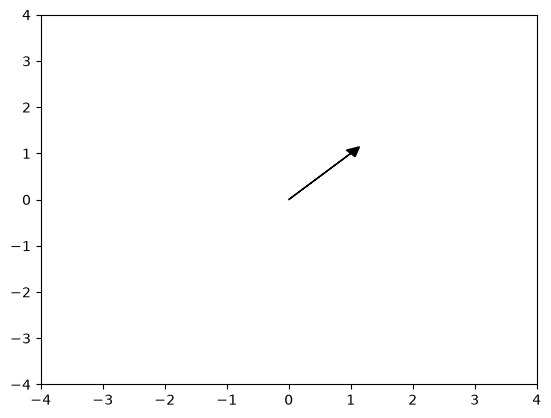

In [8]:
plot_vectors([x], axes=[4, 4], fname='transform_x.svg')

接下来，我们在同一坐标系中绘制向量 $\vec x = [1, 1]$，以及它和如下矩阵做点积得到的结果：

$$Ro = \begin{bmatrix} 2 & 0 \\ 0 & -2 \end{bmatrix}$$

$$y = x \cdot Ro = [[2, -2]]$$

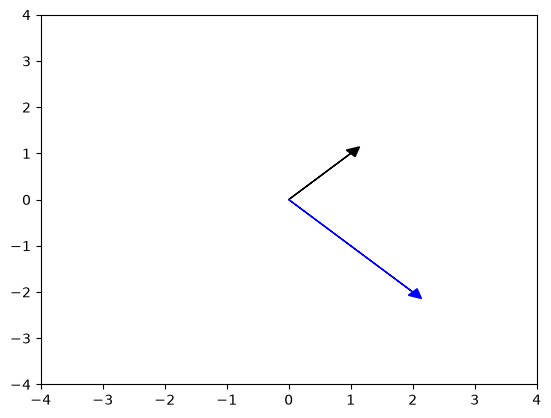

In [9]:
plot_vectors([x, y], axes=[4, 4], fname='transformx_and_y.svg')

可以看到输出向量 `y`（蓝色）经过变换得到了一个新向量。

### 示例 2

我们将使用 Pyplot 直观查看旋转变换对二维向量的作用效果。为此，我们创建了一个函数，用来处理可视化样式所有繁杂细节。下面的流程将在 Pyplot 画布中绘制箭头。

由两个实数特征构成的数据属于 $\mathbb{R} \times \mathbb{R}$（也就是 $\mathbb{R}^2$）空间。$\mathbb{R}^2$ 中的旋转矩阵可以在固定坐标系中将向量 $\vec x$ 逆时针旋转角度 $\theta$。旋转矩阵形式如下：

$$Ro = \begin{bmatrix} cos \theta & -sin \theta \\ sin \theta & cos \theta \end{bmatrix}$$

NumPy 中的三角函数要求输入角度为弧度制，而非角度制。在下一个代码单元中，我们定义一个旋转矩阵，用于将向量旋转 $45^\circ$。

In [10]:
angle = 100 * (np.pi / 180) #convert degrees to radians

Ro = np.array([[np.cos(angle), -np.sin(angle)],
              [np.sin(angle), np.cos(angle)]])

x2 = np.array([2, 2]).reshape(1, -1) # make it a row vector
y2 = np.dot(x2, Ro)

print('Rotation matrix')
print(Ro)
print('\nRotated vector')
print(y2)

print('\n x2 norm', np.linalg.norm(x2))
print('\n y2 norm', np.linalg.norm(y2))
print('\n Rotation matrix norm', np.linalg.norm(Ro))

Rotation matrix
[[-0.17364818 -0.98480775]
 [ 0.98480775 -0.17364818]]

Rotated vector
[[ 1.62231915 -2.31691186]]

 x2 norm 2.8284271247461903

 y2 norm 2.82842712474619

 Rotation matrix norm 1.414213562373095


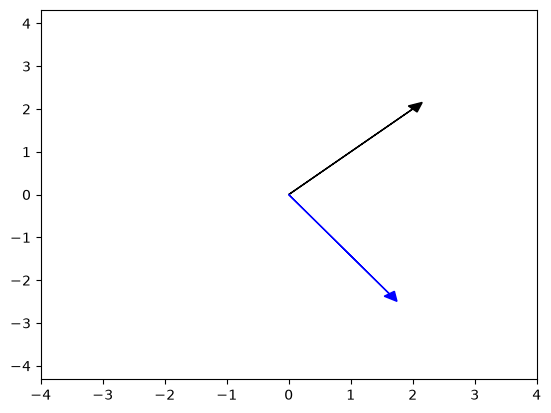

In [11]:
plot_vectors([x2, y2], fname='transform_02.svg')

Some points to note:

* The norm of the input vector is the same as the norm of the output vector. Rotations matrices do not modify the norm of the vector, only its direction.
* The norm of any $R^2$ rotation matrix is always $\sqrt 2 = 1.414221$

## Frobenius Norm

The Frobenius norm is the generalization to $R^2$ of the already known norm function for vectors 

$$\| \vec a \| = \sqrt {{\vec a} \cdot {\vec a}} $$

For a given $R^2$ matrix A, the frobenius norm is defined as:

$$\|\mathrm{A}\|_{F} \equiv \sqrt{\sum_{i=1}^{m} \sum_{j=1}^{n}\left|a_{i j}\right|^{2}}$$


In [ ]:
A = np.array([[2, 2],
              [2, 2]])

`np.square()` is a way to square each element of a matrix. It must be equivalent to use the * operator in Numpy arrays.

In [ ]:
A_squared = np.square(A)
A_squared

Now you can sum over the elements of the resulting array, and then get the square root of the sum.

In [ ]:
A_Frobenius = np.sqrt(np.sum(A_squared))
A_Frobenius

That was the extended version of the `np.linalg.norm()` function. You can check that it yields the same result.

In [ ]:
print('Frobenius norm of the Rotation matrix')
print(np.sqrt(np.sum(Ro * Ro)), '== ', np.linalg.norm(Ro))

**Congratulations!! We've covered a few more matrix operations in this lab. This will come in handy in this week's programming assignment!**